## Basic chatbot with langgraph(Graph API)

In [1]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list,add_messages]


In [3]:
graph_builder=StateGraph(State)

In [4]:
graph_builder

In [5]:
import os
from dotenv import load_dotenv
load_dotenv()


True

In [6]:
os.environ['GROQ_API_KEY'] = os.getenv('GROQ_API_KEY')

In [7]:
from langchain_groq import ChatGroq

In [8]:
from langchain_groq import ChatGroq

# model=ChatGroq(model='openai/gpt-oss-20b')
model=ChatGroq(    model="openai/gpt-oss-20b"
)

In [9]:
model

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.2', 'langchain': '1.4.0'}}, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000013E20501DD0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000013E20671F90>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [10]:
def chatbot(state:State):
    return {'messages':[model.invoke(state['messages'])]}

In [11]:
graph_builder=StateGraph(State)

# Adding nodes
graph_builder.add_node('llmchatbot',chatbot)

## Adding edges
graph_builder.add_edge(START,'llmchatbot')
graph_builder.add_edge('llmchatbot', END)

## Compiling the graph
graph=graph_builder.compile()

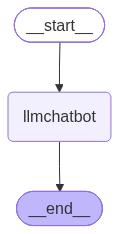

In [12]:
## Visualize the graph
from IPython.display import Image,display

try:
    
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [13]:
response=graph.invoke({'messages':[{'role':'user','content':'Hello!'}]})

In [14]:
response['messages']

[HumanMessage(content='Hello!', additional_kwargs={}, response_metadata={}, id='80ddd532-f0e2-4588-85b0-487cc743227b'),
 AIMessage(content='Hello! 👋 How can I help you today?', additional_kwargs={'reasoning_content': 'User says "Hello!" This is a greeting. We should respond politely.'}, response_metadata={'token_usage': {'completion_tokens': 36, 'prompt_tokens': 73, 'total_tokens': 109, 'completion_time': 0.044141139, 'completion_tokens_details': {'reasoning_tokens': 16}, 'prompt_time': 0.005427128, 'prompt_tokens_details': None, 'queue_time': 0.212364111, 'total_time': 0.049568267}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_a12402de73', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a08f4d-0150-7da1-9f60-bc2c4847a3a7-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 73, 'output_tokens': 36, 'total_tokens': 109, 'output_token_details': {'reasoning': 16}})]

In [15]:
for event in graph.stream({"messages":"Hi How are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

Hi there! I’m doing great—thanks for asking. How can I help you today?


### Chatbot With Toolm


In [16]:
from langchain_tavily import TavilySearch
tool=TavilySearch(max_results=2)
tool.invoke('What is langgraph')

{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'title': 'What is LangGraph?',
   'url': 'https://www.ibm.com/think/topics/langgraph',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. [...] LangGraph illuminates the processes within an AI workflow, allowing full transparency of the agent’s state. Within LangGraph, the “state” feature serves as a memory bank that records and tracks all the valuable information processed by the AI system. It’s similar to a digital notebook where the system captures and upda

In [17]:
## Custom function
## Custom function
def multiply(a:int,b:int)->int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b

In [18]:
tools=[tool,multiply]

In [19]:
llm_with_tools=model.bind_tools(tools)

In [20]:
llm_with_tools

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.2', 'langchain': '1.4.0'}}, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000013E20501DD0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000013E20671F90>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and 

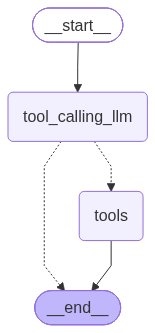

In [21]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))



In [22]:
response=graph.invoke({"messages":"What is the recent ai news"})

In [23]:
response['messages'][-1].content

'{"query": "latest AI news 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://aiweekly.co/ai-news-today", "title": "AI News Today, September 10: Top Stories | AI Weekly", "content": "At JD\'s 2026 Global Technology Explorers Conference, JD Cloud unveiled plans for a 100,000-GPU intelligent computing cluster built entirely on Moore Threads\' full-featured domestic GPUs — described as the first Chinese-silicon cluster at 100K scale operated by a major domestic cloud provider. Workloads target large-model training, inference and embodied AI, following an earlier 10K-GPU cluster the two firms co-deployed.\\n\\nanthropic.com 1d ago ALERT 28 [...] Positron closed a two-tranche $875M Series C at a $5B post-money valuation, with a $375M tranche co-led by NEA, Atreides, Valor, Andra Capital and SemiAnalysis Capital, plus a Series C-1 of up to $500M anchored by Netscape co-founder Jim Clark. Its Asimov chip skips HBM in favor of 288GB-2,304GB of LPDDR5

In [24]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the recent ai news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_1b9c4249-dd44-4ce3-a7c1-d26ebe23b710)
 Call ID: fc_1b9c4249-dd44-4ce3-a7c1-d26ebe23b710
  Args:
    query: latest AI news 2026
    search_depth: basic
    time_range: week
    topic: general
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://aiweekly.co/ai-news-today", "title": "AI News Today, September 10: Top Stories | AI Weekly", "content": "At JD's 2026 Global Technology Explorers Conference, JD Cloud unveiled plans for a 100,000-GPU intelligent computing cluster built entirely on Moore Threads' full-featured domestic GPUs — described as the first Chinese-silicon cluster at 100K scale operated b

In [25]:
response=graph.invoke({"messages":"What is 5 multiplied by 2"})
for m in response['messages']:
    m.pretty_print()


================================ Human Message =================================

What is 5 multiplied by 2
================================== Ai Message ==================================

5 multiplied by 2 equals **10**.


In [26]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_7bc8deef-b758-412c-8287-942a0a45e1a0)
 Call ID: fc_7bc8deef-b758-412c-8287-942a0a45e1a0
  Args:
    query: recent AI news
    search_depth: advanced
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://blog.google/innovation-and-ai/technology/google-ai-updates-august-2026", "title": "The latest AI news we announced in August 2026 - Google Blog", "content": "In August, we continued advancing AI responsibly — making it faster, more accessible, and truly practical for everyone, from software developers and students to creatives and scientists. We’re bringing intellige

### ReAct Agent Architecture

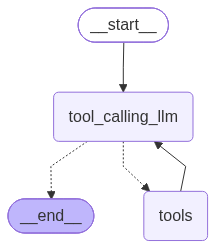

In [29]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [30]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_1346ee5e-4d6a-4ec5-a1ba-93a8005514f9)
 Call ID: fc_1346ee5e-4d6a-4ec5-a1ba-93a8005514f9
  Args:
    query: recent AI news 2026
    search_depth: basic
    time_range: month
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://blog.google/innovation-and-ai/technology/google-ai-updates-august-2026", "title": "The latest AI news we announced in August 2026 - Google Blog", "content": "Generate videos with more control using Gemini Omni 1.1 Flash. We introduced Gemini Omni 1.1 Flash to bring people even more precision and control for generating videos. The new capa